### IMPORTANDO BIBLIOTECAS E A BASE DE DADOS


In [1]:
# Importando as bibliotecas necessárias

import pandas as pd
import openpyxl
import pathlib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import train_test_split

In [2]:
# Criei um dicionário onde o valor é referente ao dia do mês    
meses = {"jan": 1, "fev": 2, "mar": 3, "abr": 4, "mai": 5, "jun": 6, "jul": 7, "ago": 8, "set": 9, "out": 10, "nov": 11, "dez": 12}

caminho_bases = pathlib.Path('dataset')

base_airbnb = pd.DataFrame()

lista_df = []

# Este loop irá percorrer cada arquivo dentro da pasta dataset e adicionar na lista_df
for arquivo in caminho_bases.iterdir():

    # Nessa duas linha seguidas, trasformo o nome mes em um número. Ex: jan -> 1
    nome_mes = arquivo.name[:3]
    mes = meses[nome_mes]
    
    # Nessas duas linhas aqui, pego os 8 ultimos dígitos e retiro a extensap .csv e deixo vazio
    ano = arquivo.name[-8:]
    ano = int(ano.replace(".csv", ""))

    df = pd.read_csv(caminho_bases / arquivo.name)

    # Auqui crios duas novas tabelas
    df["mes"] = mes
    df["ano"] = ano

    lista_df.append(df)

# Aqui junta todos os df, depois cria um df único reorganizando os indices 
base_airbnb = pd.concat(lista_df, ignore_index=True)


display(base_airbnb)


/tmp/ipykernel_30034/2614473999.py:21: DtypeWarning: Columns (0: weekly_price, 1: monthly_price, 2: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_bases / arquivo.name)
/tmp/ipykernel_30034/2614473999.py:21: DtypeWarning: Columns (0: weekly_price, 1: monthly_price, 2: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_bases / arquivo.name)
/tmp/ipykernel_30034/2614473999.py:21: DtypeWarning: Columns (0: weekly_price, 1: monthly_price, 2: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_bases / arquivo.name)
/tmp/ipykernel_30034/2614473999.py:21: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_bases / arquivo.name)
/tmp/ipykernel_30034/2614473999.py:21: DtypeWarning: Columns (0: weekly_price, 1: monthly_price, 2: license

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,mes,ano
0,17878,https://www.airbnb.com/rooms/17878,20190313042552,2019-03-13,Very Nice 2Br - Copacabana - WiFi,Please note that special rates apply for New Y...,- large balcony which looks out on pedestrian ...,Please note that special rates apply for New Y...,none,This is the best spot in Rio. Everything happe...,...,strict_14_with_grace_period,f,f,1,1.0,0.0,0.0,2.10,3,2019
1,25026,https://www.airbnb.com/rooms/25026,20190313042552,2019-03-13,Beautiful Modern Decorated Studio in Copa,"Our apartment is a little gem, everyone loves ...",This newly renovated studio (last renovations ...,"Our apartment is a little gem, everyone loves ...",none,Copacabana is a lively neighborhood and the ap...,...,strict_14_with_grace_period,t,t,3,3.0,0.0,0.0,2.12,3,2019
2,31560,https://www.airbnb.com/rooms/31560,20190313042552,2019-03-13,NICE & COZY 1BDR - IPANEMA BEACH,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,none,Die Nachbarschaft von Ipanema ist super lebend...,...,strict_14_with_grace_period,f,f,1,1.0,0.0,0.0,2.32,3,2019
3,34608,https://www.airbnb.com/rooms/34608,20190313042552,2019-03-13,São-Conrado House with Ocean View,NaN,Its a House inside a very good condo with 2...,Its a House inside a very good condo with 2...,none,NaN,...,strict_14_with_grace_period,f,f,8,5.0,3.0,0.0,NaN,3,2019
4,35636,https://www.airbnb.com/rooms/35636,20190313042552,2019-03-13,Cosy flat close to Ipanema beach,This cosy apartment is just a few steps away ...,"The location is extremely convenient, safe and...",This cosy apartment is just a few steps away ...,none,The apartment street is very quiet and safe ....,...,strict_14_with_grace_period,t,t,1,1.0,0.0,0.0,2.16,3,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902205,35844830,https://www.airbnb.com/rooms/35844830,20190619182032,2019-06-20,Sítio da Bebel com diárias promocionais!,NaN,NaN,NaN,none,NaN,...,flexible,f,f,1,1.0,0.0,0.0,NaN,6,2019
902206,35847774,https://www.airbnb.com/rooms/35847774,20190619182032,2019-06-20,Cozy Room near the beach and Metro,"400m de distância a pé do metrô. 1,3Km de dis...",NaN,"400m de distância a pé do metrô. 1,3Km de dis...",none,NaN,...,flexible,f,f,1,0.0,1.0,0.0,NaN,6,2019
902207,35849398,https://www.airbnb.com/rooms/35849398,20190619182032,2019-06-20,Lodge Sítio Leotaianne,"Featuring a garden, an outdoor pool and garden...",The lodge with a balcony and pool views featur...,"Featuring a garden, an outdoor pool and garden...",none,"The nearest airport is Santos Dumont Airport, ...",...,flexible,f,f,1,0.0,1.0,0.0,NaN,6,2019
902208,35856723,https://www.airbnb.com/rooms/35856723,20190619182032,2019-06-20,Charming beach apt in quite corner near everyt...,"This is a great apt in Leme, in front of the b...",This is a great apartment to stay or work and ...,"This is a great apt in Leme, in front of the b...",none,I am from Ireland but I have lived in Rio for ...,...,flexible,f,f,1,1.0,0.0,0.0,NaN,6,2019


In [3]:
# Filtrei os 1000 primeiros registros da miha base_airbnb, e transformei em arquivo excel
# Fiz isso para poder ver quais colunas não seriam necesárias para minha análise e excluí-las, facilitando o trabalho
base_airbnb.head(1000).to_excel("primeiros_registros.xlsx")

In [4]:
# Lista com os nomes das colunas que serão necessárias
colunas = ["host_response_time", "host_response_rate", "host_acceptance_rate", "host_is_superhost", "host_listings_count", "latitude", "longitude", "is_location_exact", "property_type", "room_type", "accommodates", "bathrooms", "bedrooms", "beds", "bed_type", "amenities", "price", "security_deposit", "cleaning_fee", "guests_included", "extra_people", "minimum_nights", "maximum_nights", "number_of_reviews", "review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin", "review_scores_communication", "review_scores_location", "review_scores_value", "instant_bookable", "is_business_travel_ready", "cancellation_policy", "mes", "ano"]

# Aqui tiro da base as colunas desnecessárias, e deixo so as que eu listei em colunas
base_airbnb = base_airbnb.loc[:, colunas]
display(base_airbnb)


,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,latitude,longitude,is_location_exact,property_type,room_type,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,is_business_travel_ready,cancellation_policy,mes,ano
0,within an hour,100%,NaN,f,2.0,-22.96592,-43.17896,t,Condominium,Entire home/apt,...,10.0,10.0,10.0,10.0,9.0,t,f,strict_14_with_grace_period,3,2019
1,within a day,92%,NaN,t,3.0,-22.97712,-43.19045,t,Apartment,Entire home/apt,...,10.0,9.0,10.0,10.0,9.0,f,f,strict_14_with_grace_period,3,2019
2,within an hour,100%,NaN,t,1.0,-22.98302,-43.21427,t,Apartment,Entire home/apt,...,10.0,10.0,10.0,10.0,10.0,t,f,strict_14_with_grace_period,3,2019
3,within an hour,100%,NaN,f,8.0,-22.99867,-43.27137,f,House,Entire home/apt,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,3,2019
4,within a day,90%,NaN,t,1.0,-22.98816,-43.19359,t,Apartment,Entire home/apt,...,9.0,10.0,10.0,10.0,10.0,f,f,strict_14_with_grace_period,3,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902205,within an hour,100%,NaN,f,3.0,-22.85619,-43.24279,f,Cottage,Entire home/apt,...,NaN,NaN,NaN,NaN,NaN,t,f,flexible,6,2019
902206,NaN,NaN,NaN,f,1.0,-22.95501,-43.18327,t,Apartment,Private room,...,NaN,NaN,NaN,NaN,NaN,t,f,flexible,6,2019
902207,NaN,NaN,NaN,f,1.0,-23.00043,-43.35420,t,House,Private room,...,NaN,NaN,NaN,NaN,NaN,t,f,flexible,6,2019
902208,NaN,NaN,NaN,f,1.0,-22.96233,-43.16693,t,Apartment,Entire home/apt,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,6,2019


## Tratando Valores Nulos


In [5]:
# Este loop vai percorrer a base e verificar quantos valores nulos tem na coluna
# se eles forem maiores que 300000 irão ser removidos, facilitando e ajudando assim a minha análise
for coluna in base_airbnb:
    if base_airbnb[coluna].isnull().sum() > 300000:
        base_airbnb = base_airbnb.drop(coluna, axis=1)
print(base_airbnb.isnull().sum())

# Aqui agora removo as linhas com valore nulos restantes
base_airbnb = base_airbnb.dropna()
print(base_airbnb.shape)

host_is_superhost            460
host_listings_count          460
latitude                       0
longitude                      0
is_location_exact              0
property_type                  0
room_type                      0
accommodates                   0
bathrooms                   1724
bedrooms                     850
beds                        2502
bed_type                       0
amenities                      0
price                          0
guests_included                0
extra_people                   0
minimum_nights                 0
maximum_nights                 0
number_of_reviews              0
instant_bookable               0
is_business_travel_ready       0
cancellation_policy            0
mes                            0
ano                            0
dtype: int64
(897709, 24)


### Ajeitando os Tipos de Dados

In [6]:
# Printa os tipos dos dados
print(base_airbnb.dtypes)
# Printa o dado 
print(base_airbnb.iloc[0])

# Aqui troca o ("$" e a ",") por vazio, e converte o tipo de dado str para float32
base_airbnb["price"] = base_airbnb["price"].str.replace("$", "")
base_airbnb["price"] = base_airbnb["price"].str.replace(",", "")
base_airbnb["price"] = base_airbnb["price"].astype(np.float32, copy=False)



# Aqui troca o ("$" e a ",") por vazio, e converte o tipo de dado str para float32
base_airbnb["extra_people"] = base_airbnb["extra_people"].str.replace("$", "")
base_airbnb["extra_people"] = base_airbnb["extra_people"].str.replace(",", "")
base_airbnb["extra_people"] = base_airbnb["extra_people"].astype(np.float32, copy=False)

# Verificando os tipos
print(base_airbnb.dtypes)

host_is_superhost               str
host_listings_count         float64
latitude                    float64
longitude                   float64
is_location_exact               str
property_type                   str
room_type                       str
accommodates                  int64
bathrooms                   float64
bedrooms                    float64
beds                        float64
bed_type                        str
amenities                       str
price                           str
guests_included               int64
extra_people                    str
minimum_nights                int64
maximum_nights                int64
number_of_reviews             int64
instant_bookable                str
is_business_travel_ready        str
cancellation_policy             str
mes                           int64
ano                           int64
dtype: object
host_is_superhost                                                           f
host_listings_count                         

/tmp/ipykernel_30034/646783748.py:9: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  base_airbnb["price"] = base_airbnb["price"].astype(np.float32, copy=False)


host_is_superhost               str
host_listings_count         float64
latitude                    float64
longitude                   float64
is_location_exact               str
property_type                   str
room_type                       str
accommodates                  int64
bathrooms                   float64
bedrooms                    float64
beds                        float64
bed_type                        str
amenities                       str
price                       float32
guests_included               int64
extra_people                float32
minimum_nights                int64
maximum_nights                int64
number_of_reviews             int64
instant_bookable                str
is_business_travel_ready        str
cancellation_policy             str
mes                           int64
ano                           int64
dtype: object


/tmp/ipykernel_30034/646783748.py:16: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  base_airbnb["extra_people"] = base_airbnb["extra_people"].astype(np.float32, copy=False)


### Analisando a Correlação Entre as Features

<Axes: >

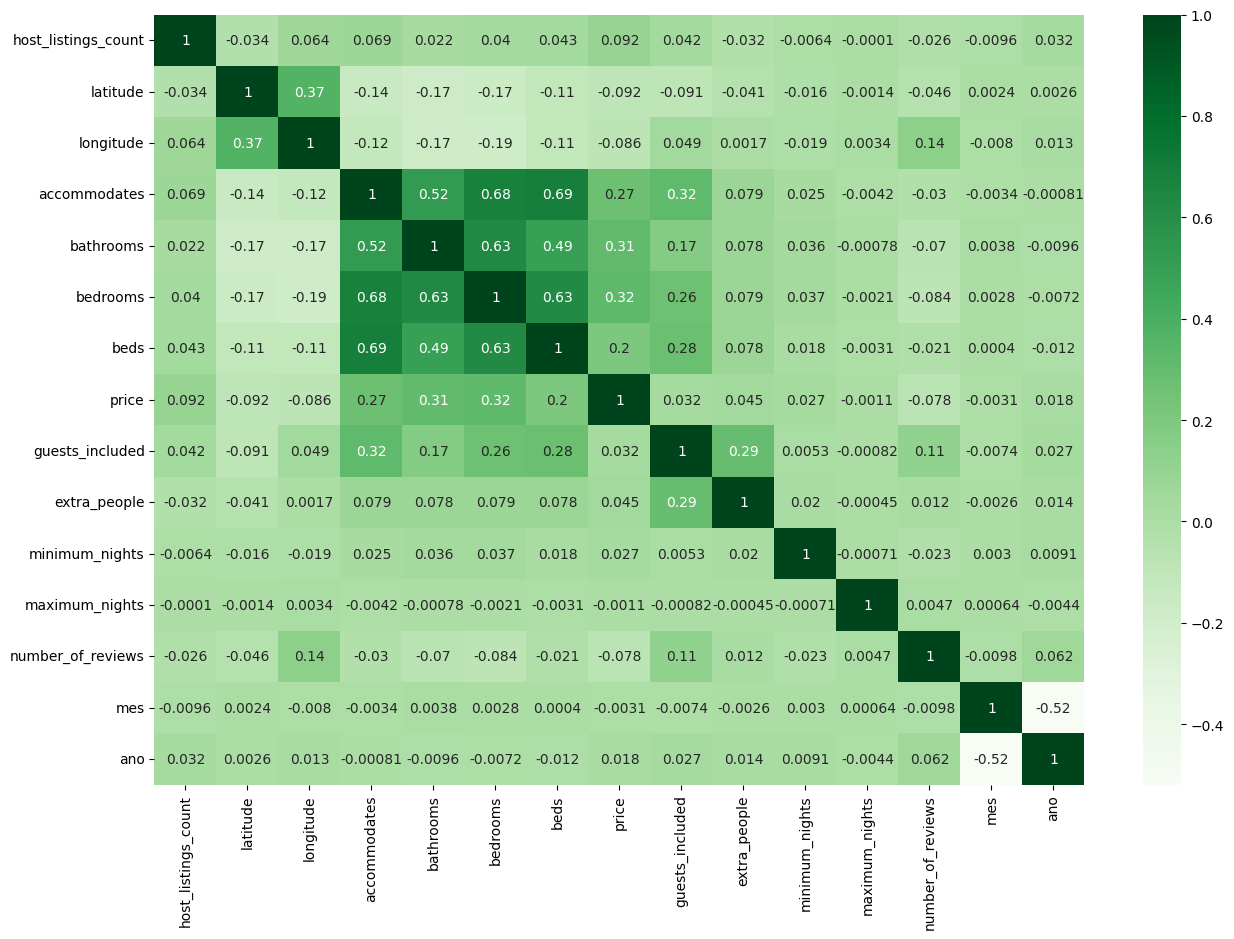

In [7]:
# Determino o tamanho do gráfico
plt.figure(figsize = (15, 10))

# Aeui seleciono so as tabelas númerias para fazer a correlação
corr = base_airbnb.select_dtypes(include=np.number).corr()

# Aqui escolho o gráfico para de correlação dos dados, e sua cor
sns.heatmap(corr, annot=True, cmap="Greens")

### Definição de funções para Análise de Outliers

In [8]:
# Esta função realiza a soma dos quartis 1 e 3
def limites(coluna):
    q1 = coluna.quantile(0.25)
    q3 = coluna.quantile(0.75)
    amplitude = q3 - q1
    return q1 - 1.5 * amplitude, q3 + 1.5 * amplitude

#### Função para excluir outliers

In [9]:
# Função para exclusão dos outliers referente ao preço
def excluir_outliers(df, nome_coluna):
    qtde_linhas = df.shape[0]
    lim_inf, lim_sup = limites(df[nome_coluna])
    df = df.loc[(df[nome_coluna] >= lim_inf) & (df[nome_coluna] <= lim_sup), :]
    linhas_removidas = qtde_linhas - df.shape[0]
    return df, linhas_removidas

In [10]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "price")

print("{} linhas removidas".format(linhas_removidas))

87282 linhas removidas


In [11]:
print(limites(base_airbnb["price"]))

(np.float64(-364.0), np.float64(1004.0))


### Diagrama de Caixa e Histograma com Seaborn

In [12]:

# Função que mostra dois gráficos de caixa
def diagrama_caixa(coluna):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(15, 5)
    sns.boxplot(x=coluna, ax=ax1)
    ax2.set_xlim(limites(coluna))
    sns.boxplot(x=coluna, ax=ax2)

# Função que mostra o histograma
def histograma(coluna):
    plt.figure(figsize=(15, 5))
    sns.histplot(coluna)

# Função que exibe gráfico em barras, e os limites sao o inf e o sup
def grafico_barra(coluna):
    plt.figure(figsize=(15, 5))
    ax = sns.barplot(x= coluna.value_counts().index, y= coluna.value_counts())
    ax.set_xlim(limites(coluna))

(810427, 24)


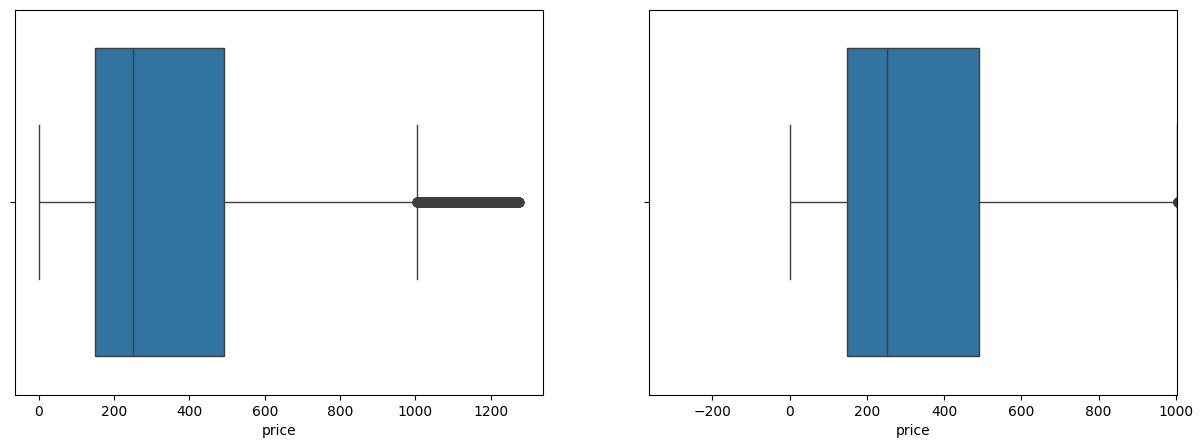

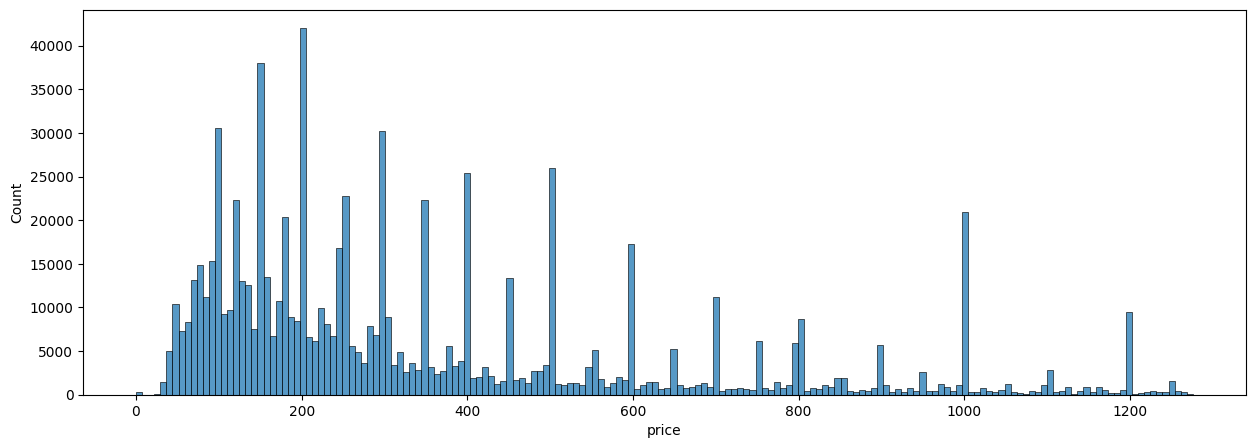

In [13]:
diagrama_caixa(base_airbnb["price"])
histograma(base_airbnb["price"])

print(base_airbnb.shape)



#### Coluna de extra_people

59194 linhas removidas


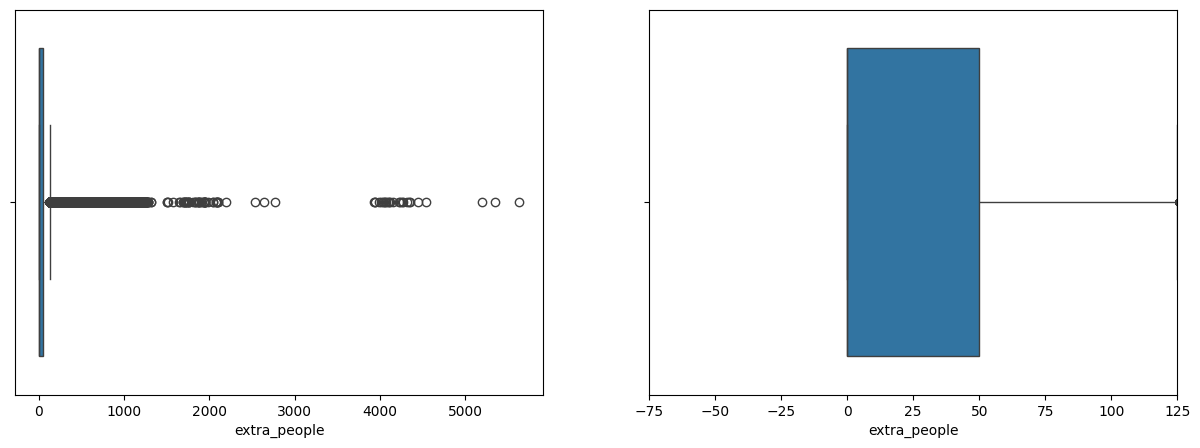

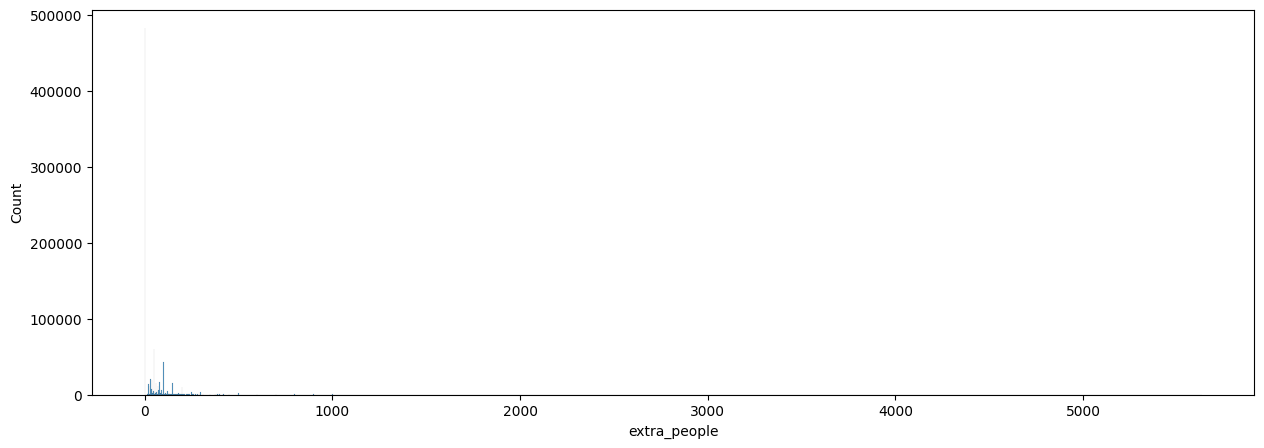

In [14]:
diagrama_caixa(base_airbnb["extra_people"])
histograma(base_airbnb["extra_people"])


base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "extra_people")

print("{} linhas removidas".format(linhas_removidas))

### Coluna host_listings_count


97723 linhas removidas


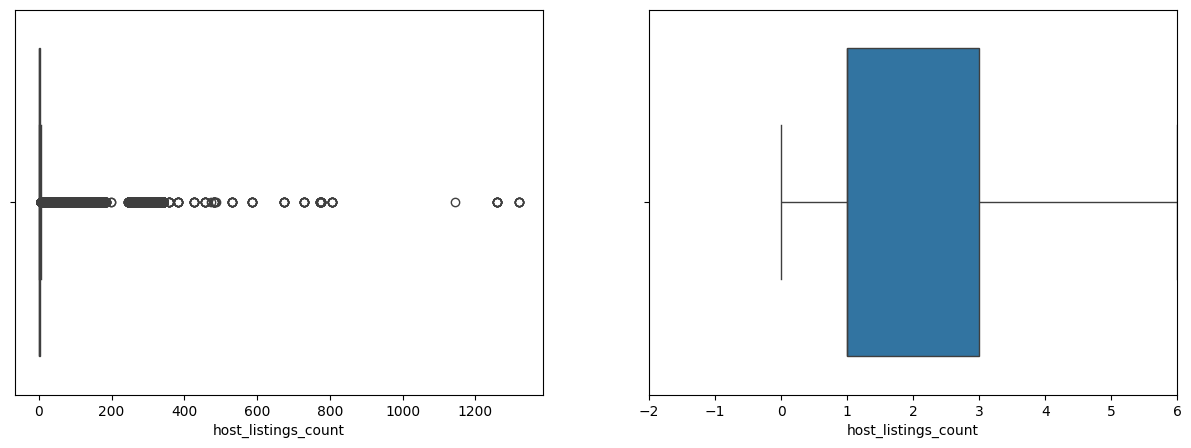

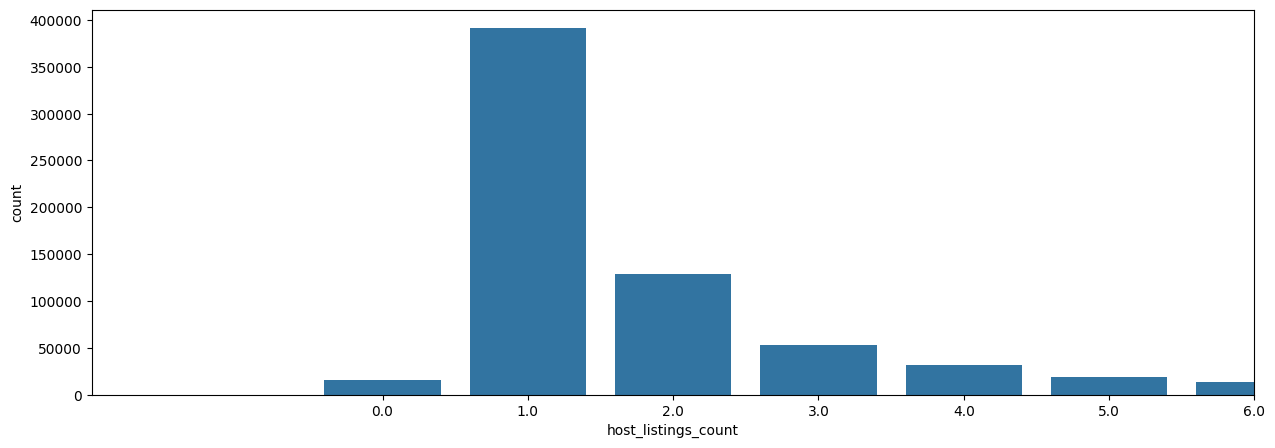

In [15]:
diagrama_caixa(base_airbnb["host_listings_count"])
grafico_barra(base_airbnb["host_listings_count"])


base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "host_listings_count")

print("{} linhas removidas".format(linhas_removidas))

### Coluna accommodates

13146 linhas removidas


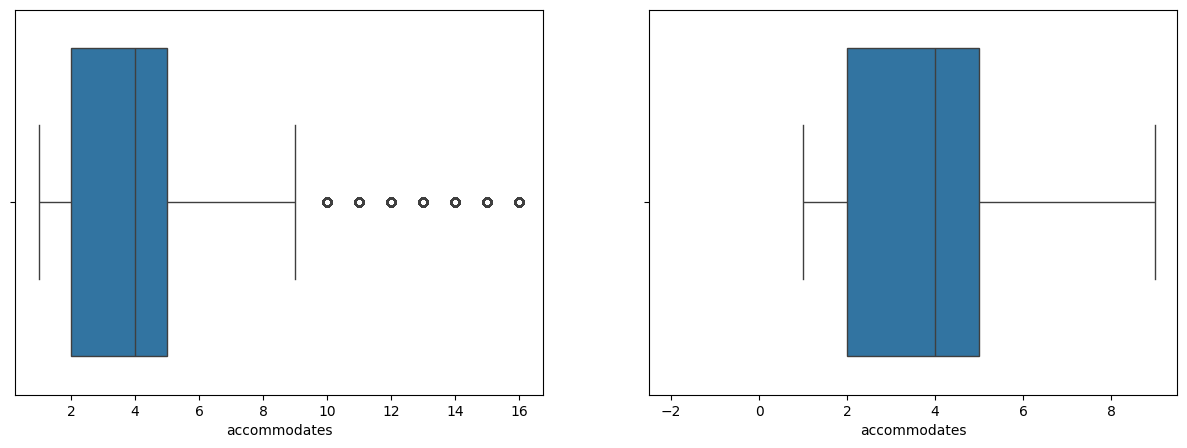

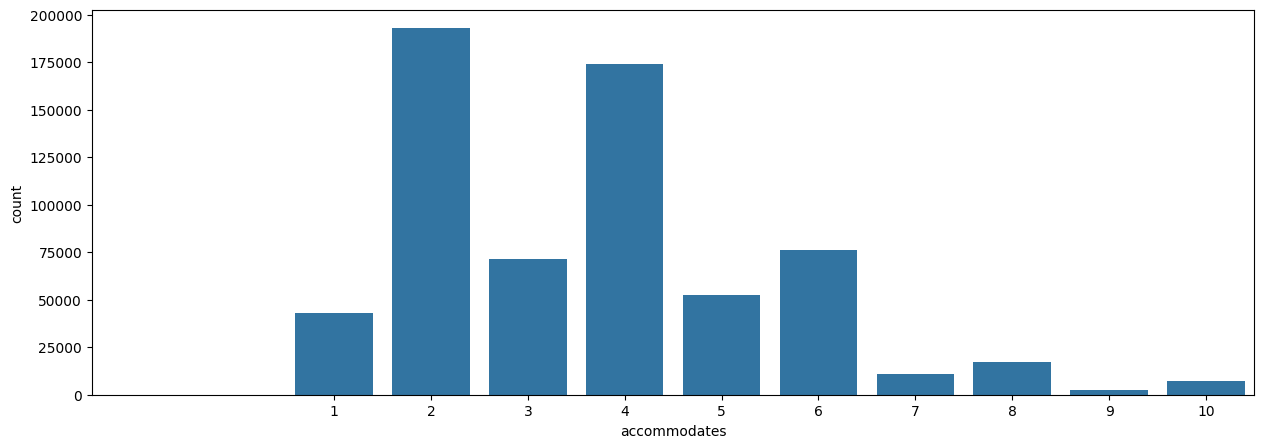

In [16]:
diagrama_caixa(base_airbnb["accommodates"])
grafico_barra(base_airbnb["accommodates"])


base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "accommodates")

print("{} linhas removidas".format(linhas_removidas))

### Coluna bathrooms

6894 linhas removidas


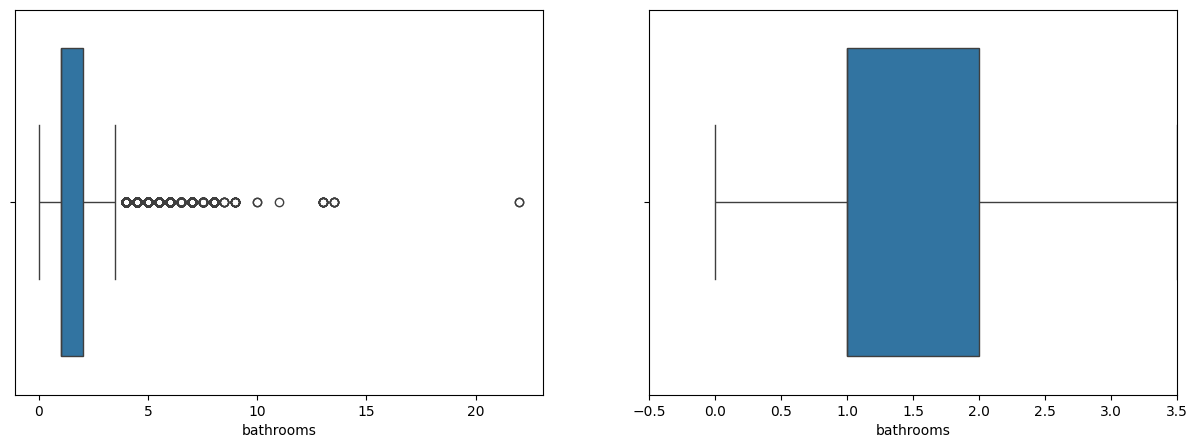

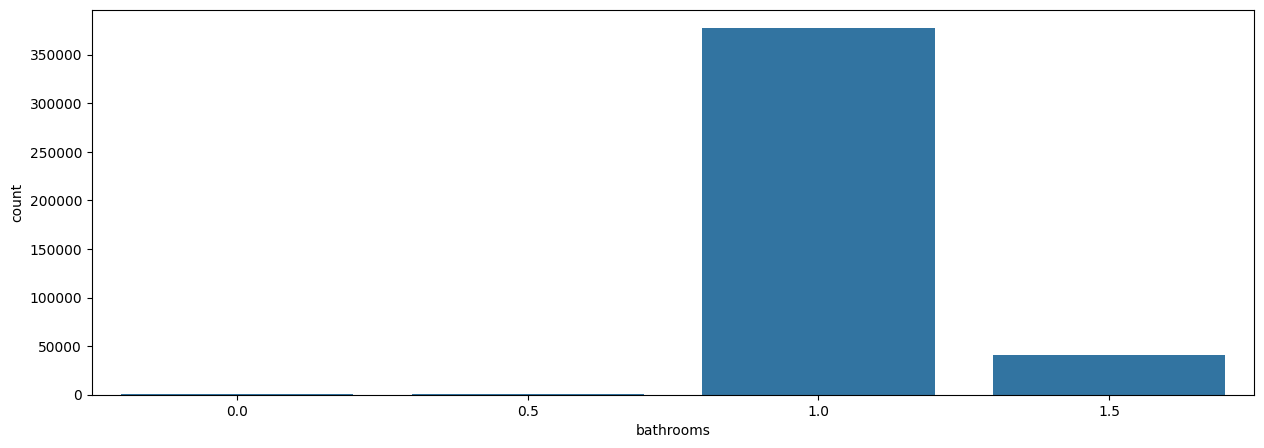

In [17]:
diagrama_caixa(base_airbnb["bathrooms"])
grafico_barra(base_airbnb["bathrooms"])


base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "bathrooms")

print("{} linhas removidas".format(linhas_removidas))

### Coluna bedrooms

5482 linhas removidas


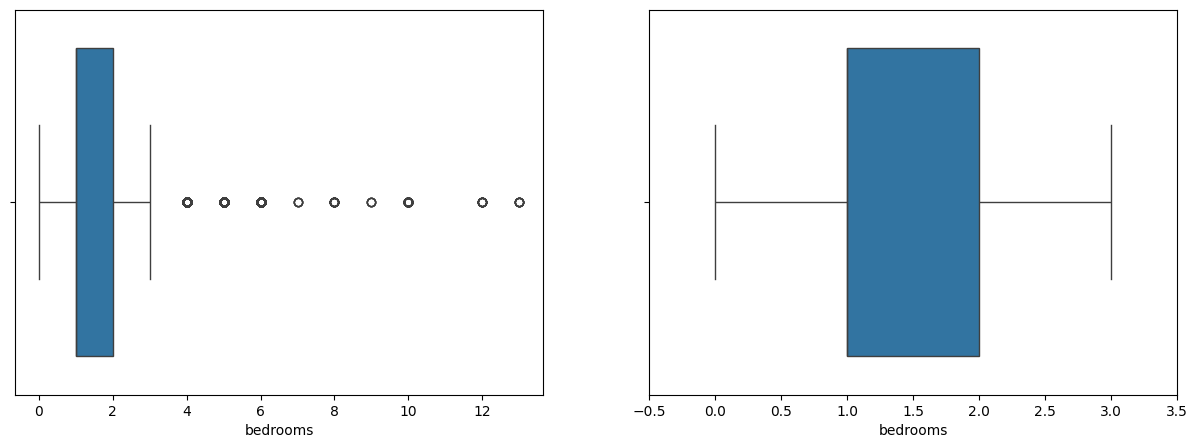

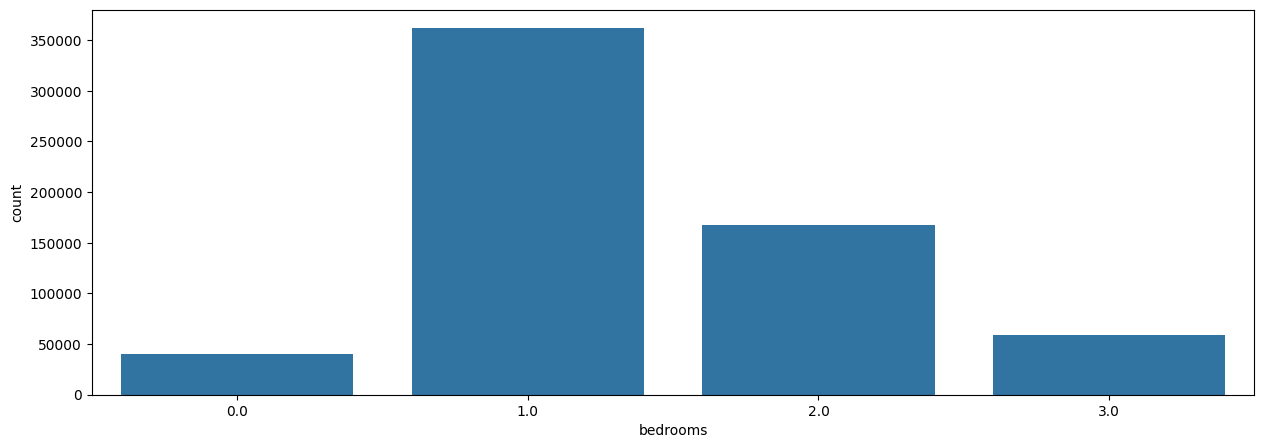

In [18]:
diagrama_caixa(base_airbnb["bedrooms"])
grafico_barra(base_airbnb["bedrooms"])


base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "bedrooms")

print("{} linhas removidas".format(linhas_removidas))

### Coluna beds

5622 linhas removidas


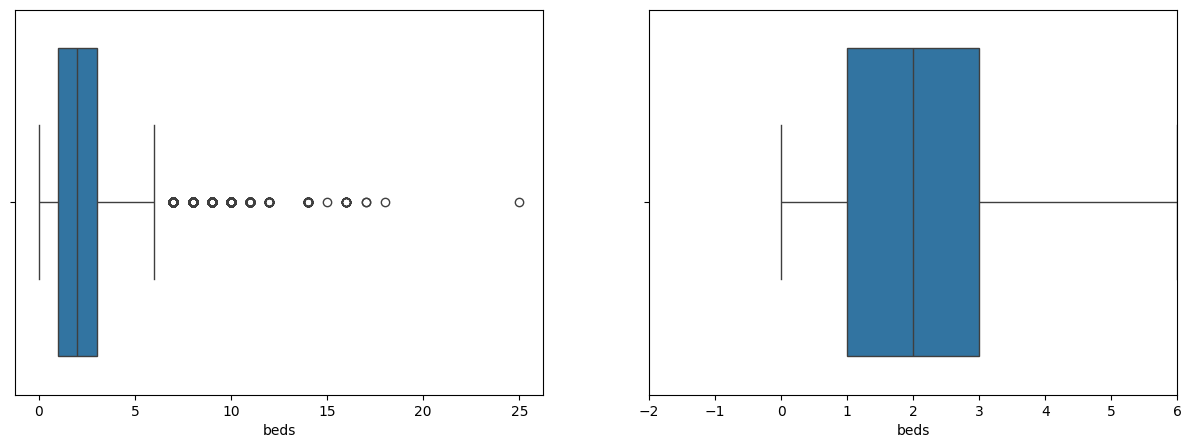

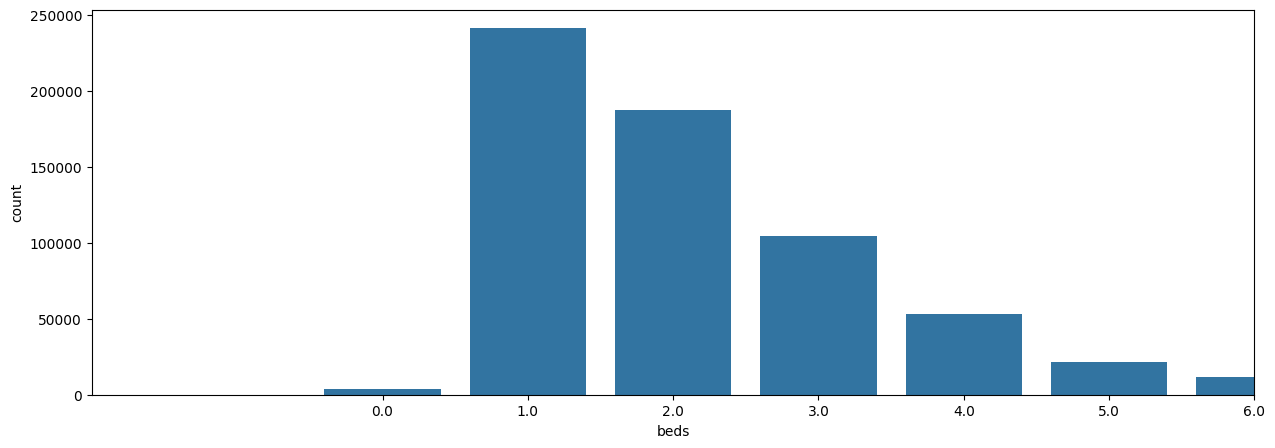

In [19]:
diagrama_caixa(base_airbnb["beds"])
grafico_barra(base_airbnb["beds"])


base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "beds")

print("{} linhas removidas".format(linhas_removidas))

### Coluna guests_included

/tmp/ipykernel_30034/1992319844.py:6: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax2.set_xlim(limites(coluna))
/tmp/ipykernel_30034/1992319844.py:18: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(limites(coluna))


(622366, 23)

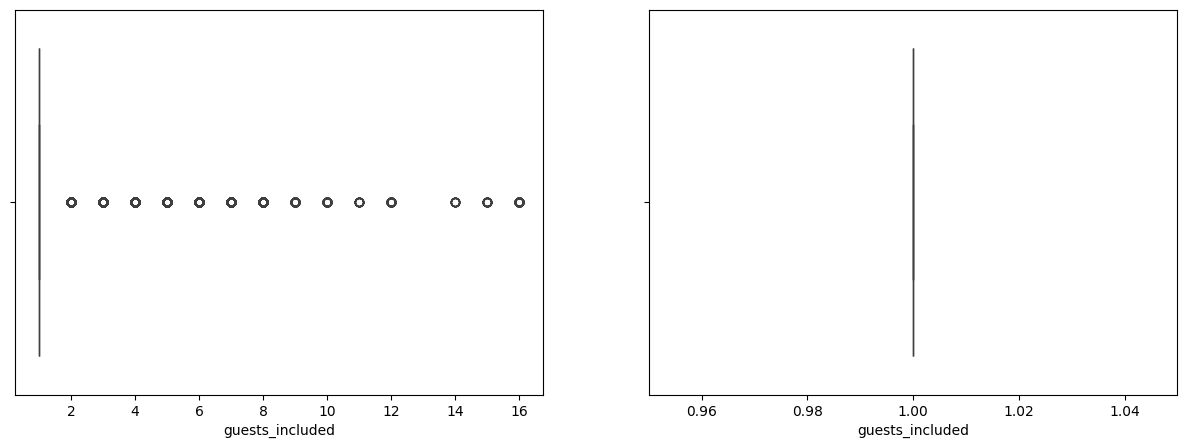

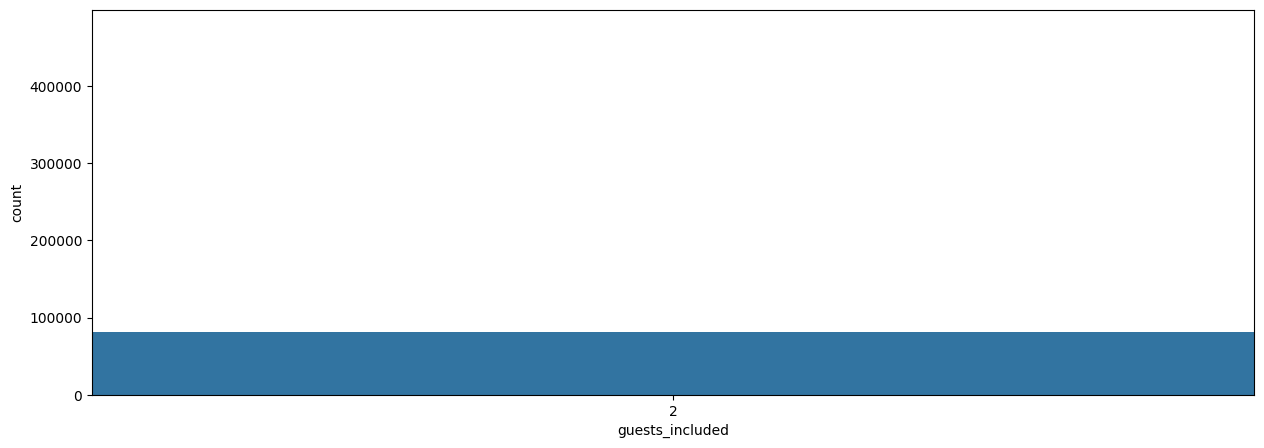

In [20]:
diagrama_caixa(base_airbnb["guests_included"])
grafico_barra(base_airbnb["guests_included"])


base_airbnb = base_airbnb.drop("guests_included", axis= 1)
base_airbnb.shape

### Coluna minimum_nights

40383 linhas removidas


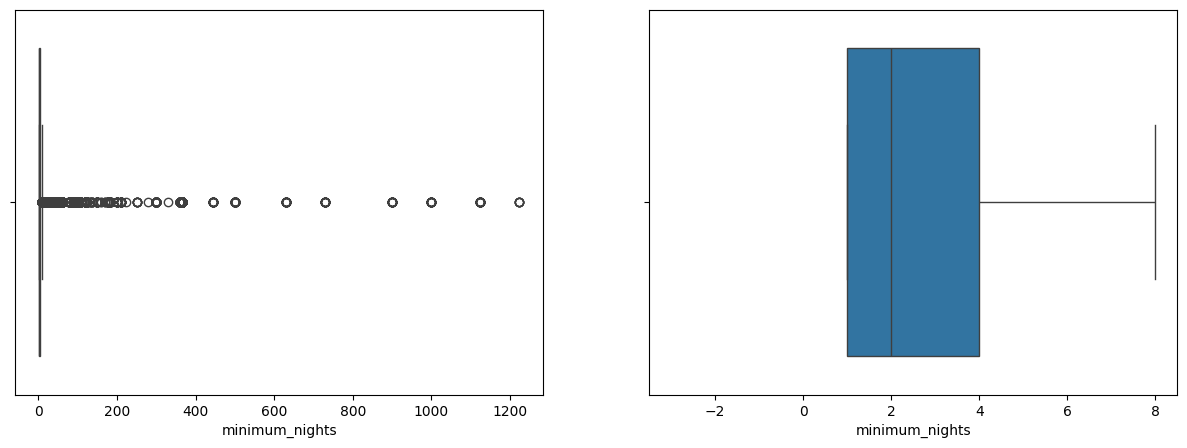

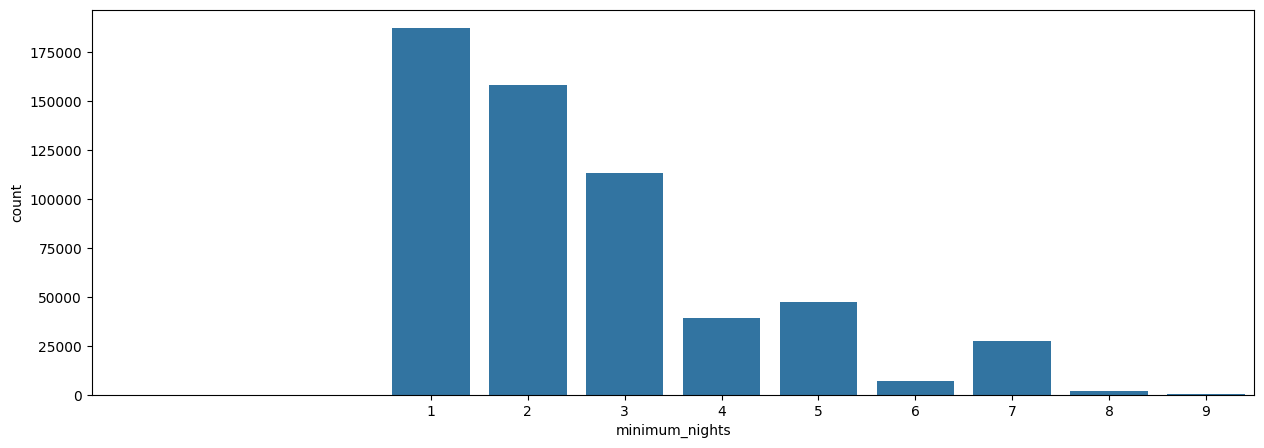

In [21]:
diagrama_caixa(base_airbnb["minimum_nights"])
grafico_barra(base_airbnb["minimum_nights"])


base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "minimum_nights")

print("{} linhas removidas".format(linhas_removidas))

### Coluna maximum_nights

(581983, 22)

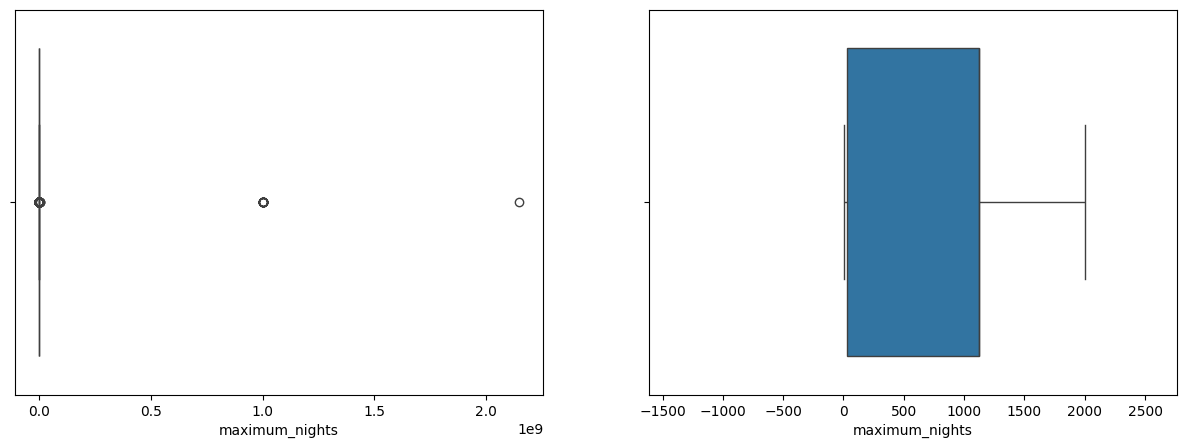

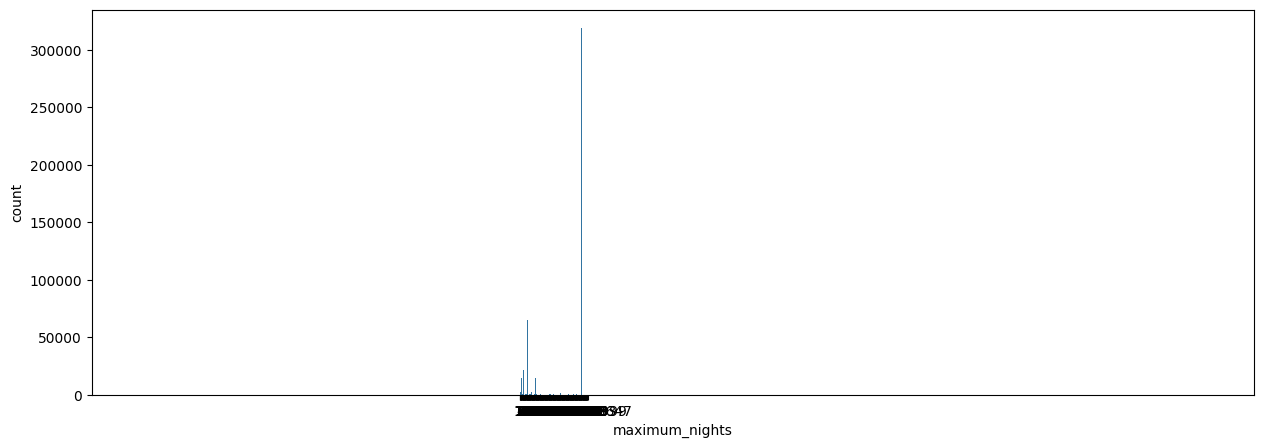

In [22]:
diagrama_caixa(base_airbnb["maximum_nights"])
grafico_barra(base_airbnb["maximum_nights"])

base_airbnb = base_airbnb.drop("maximum_nights", axis= 1)
base_airbnb.shape

### Coluna number_of_reviews

(581983, 21)

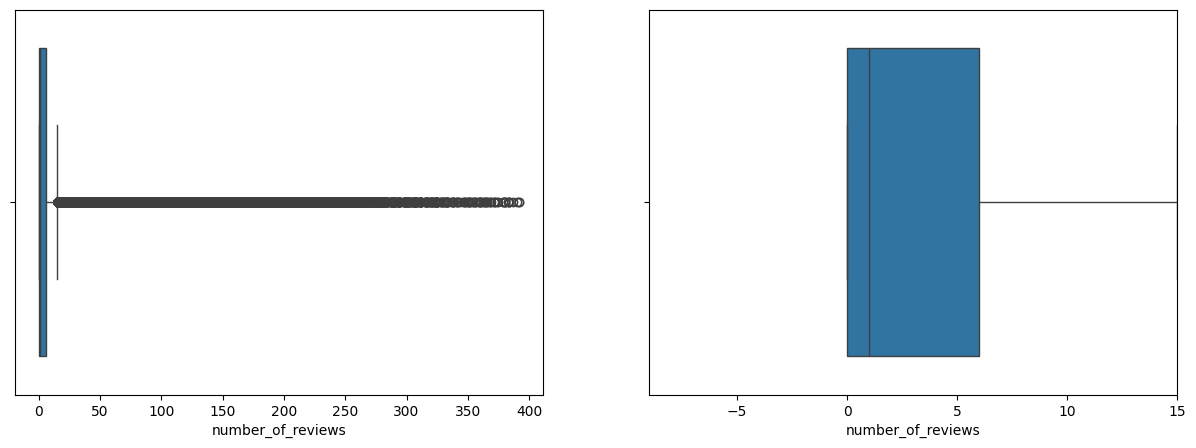

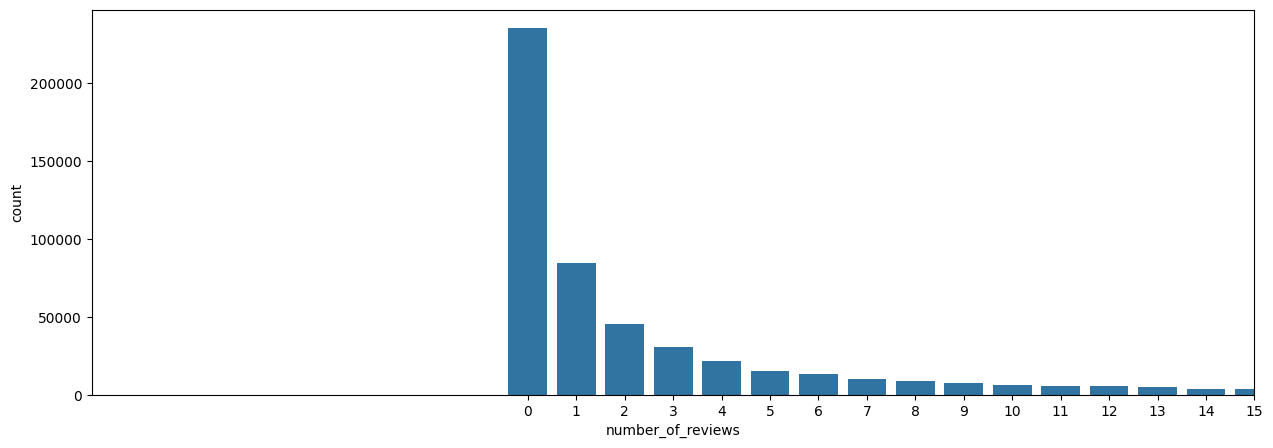

In [23]:
diagrama_caixa(base_airbnb["number_of_reviews"])
grafico_barra(base_airbnb["number_of_reviews"])

base_airbnb = base_airbnb.drop("number_of_reviews", axis= 1)
base_airbnb.shape

---

## Analisando colunas de texto

['Other', 'Villa', 'Townhouse', 'Aparthotel', 'Chalet', 'Earth house', 'Tiny house', 'Boutique hotel', 'Hotel', 'Casa particular (Cuba)', 'Cottage', 'Bungalow', 'Dorm', 'Cabin', 'Nature lodge', 'Castle', 'Treehouse', 'Island', 'Boat', 'Hut', 'Campsite', 'Resort', 'Camper/RV', 'Yurt', 'Tent', 'Tipi', 'Barn', 'Farm stay', 'Pension (South Korea)', 'Dome house', 'Igloo', 'In-law', 'Vacation home', 'Houseboat', 'Timeshare', 'Pousada', 'Casa particular', 'Plane']
property_type
Apartment             458354
House                  51387
Condominium            26456
Serviced apartment     12671
Loft                   12352
Outros                  8850
Guest suite             3621
Bed and breakfast       3472
Hostel                  2665
Guesthouse              2155
Name: count, dtype: int64


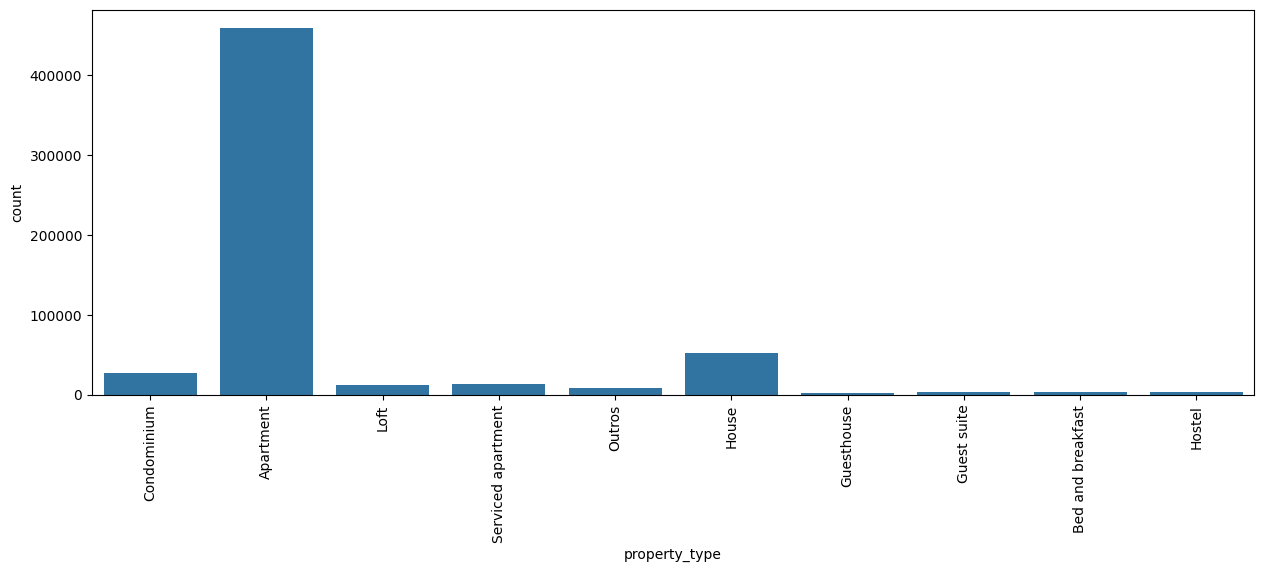

In [24]:
tabela_tipos_casa = base_airbnb["property_type"].value_counts()
colunas_agrupar = []

for tipo in tabela_tipos_casa.index:
    if tabela_tipos_casa[tipo] < 2000:
        colunas_agrupar.append(tipo)
print(colunas_agrupar)

for tipo in colunas_agrupar:
    base_airbnb.loc[base_airbnb["property_type"] == tipo, "property_type"] = "Outros"

print(base_airbnb["property_type"].value_counts())
plt.figure(figsize=(15, 5))
grafico = sns.countplot(x = "property_type", data=base_airbnb)
grafico.tick_params(axis="x", rotation=90)

### Coluna room_type

room_type
Entire home/apt    372443
Private room       196859
Shared room         11714
Hotel room            967
Name: count, dtype: int64


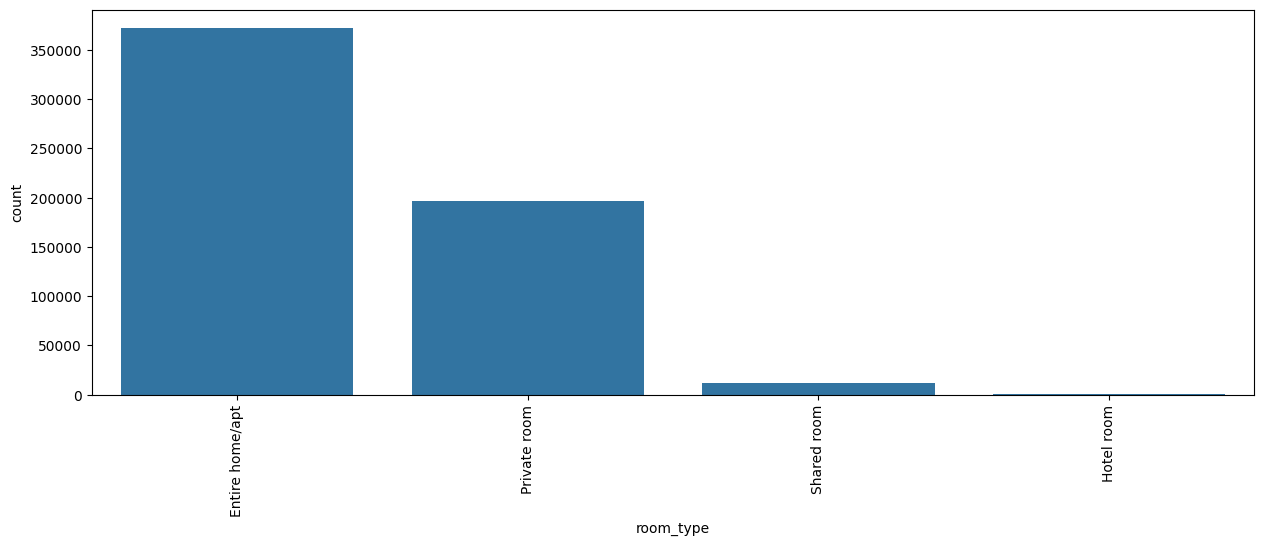

In [25]:
print(base_airbnb["room_type"].value_counts())
plt.figure(figsize=(15, 5))
grafico = sns.countplot(x = "room_type", data=base_airbnb)
grafico.tick_params(axis="x", rotation=90)

### Coluna bed_type

bed_type
Real Bed         570643
Pull-out Sofa      8055
Futon              1634
Airbed             1155
Couch               496
Name: count, dtype: int64
['Pull-out Sofa', 'Futon', 'Airbed', 'Couch']
bed_type
Real Bed    570643
Outros       11340
Name: count, dtype: int64


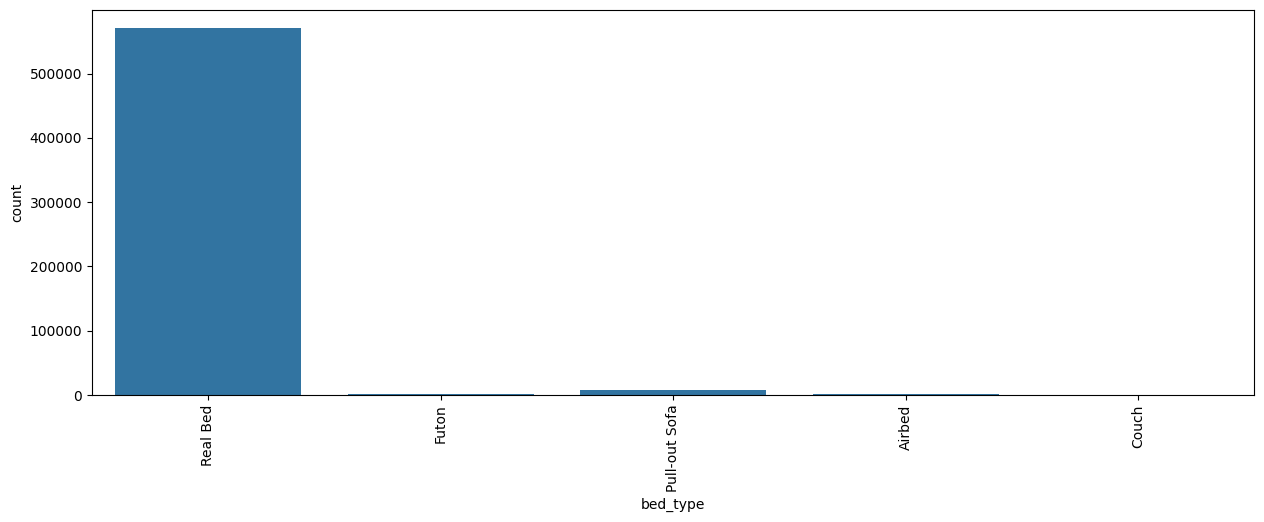

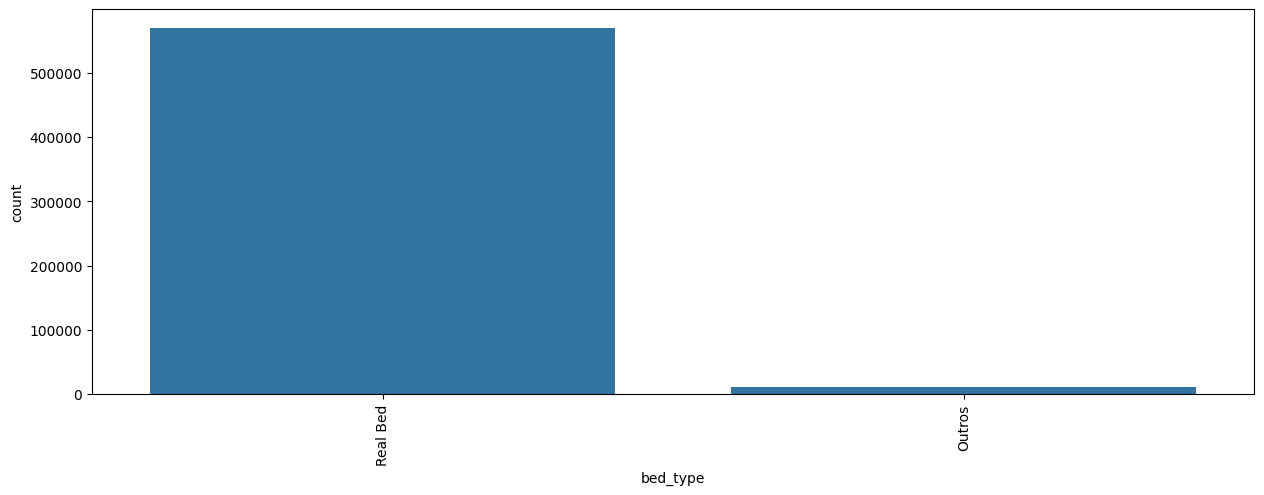

In [26]:
print(base_airbnb["bed_type"].value_counts())
plt.figure(figsize=(15, 5))
grafico = sns.countplot(x = "bed_type", data=base_airbnb)
grafico.tick_params(axis="x", rotation=90)


tabela_tipos_casa = base_airbnb["bed_type"].value_counts()
colunas_agrupar = []

for tipo in tabela_tipos_casa.index:
    if tabela_tipos_casa[tipo] < 10000:
        colunas_agrupar.append(tipo)
print(colunas_agrupar)

for tipo in colunas_agrupar:
    base_airbnb.loc[base_airbnb["bed_type"] == tipo, "bed_type"] = "Outros"


print(base_airbnb["bed_type"].value_counts())
plt.figure(figsize=(15, 5))
grafico = sns.countplot(x = "bed_type", data=base_airbnb)
grafico.tick_params(axis="x", rotation=90)

### Coluna cancellation_policy

cancellation_policy
flexible                       258096
strict_14_with_grace_period    200743
moderate                       113281
strict                           9696
super_strict_60                   135
super_strict_30                    32
Name: count, dtype: int64
['strict', 'super_strict_60', 'super_strict_30']
cancellation_policy
flexible                       258096
strict_14_with_grace_period    200743
moderate                       113281
strict                           9863
Name: count, dtype: int64


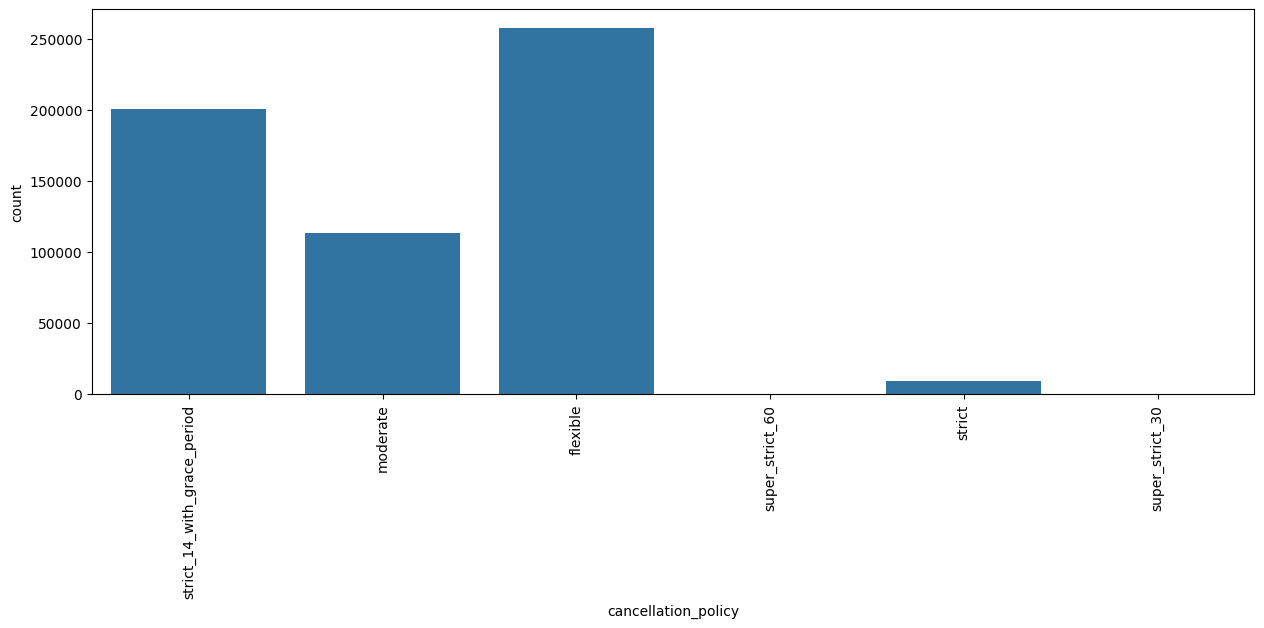

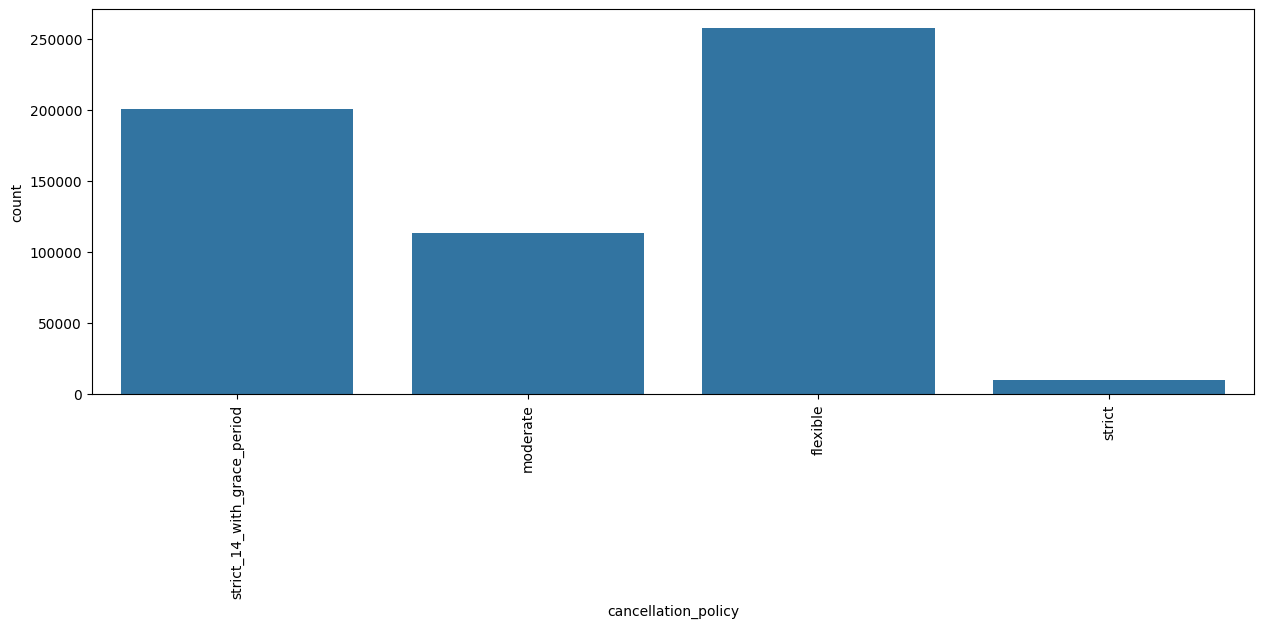

In [27]:
print(base_airbnb["cancellation_policy"].value_counts())
plt.figure(figsize=(15, 5))
grafico = sns.countplot(x = "cancellation_policy", data=base_airbnb)
grafico.tick_params(axis="x", rotation=90)


tabela_tipos_casa = base_airbnb["cancellation_policy"].value_counts()
colunas_agrupar = []

for tipo in tabela_tipos_casa.index:
    if tabela_tipos_casa[tipo] < 10000:
        colunas_agrupar.append(tipo)
print(colunas_agrupar)

for tipo in colunas_agrupar:
    base_airbnb.loc[base_airbnb["cancellation_policy"] == tipo, "cancellation_policy"] = "strict"


print(base_airbnb["cancellation_policy"].value_counts())
plt.figure(figsize=(15, 5))
grafico = sns.countplot(x = "cancellation_policy", data=base_airbnb)
grafico.tick_params(axis="x", rotation=90)

### Coluna amenities

In [28]:
print(base_airbnb["amenities"].iloc[0].split(","))
print(len(base_airbnb["amenities"].iloc[0].split(",")))

base_airbnb["n_amenities"] = base_airbnb["amenities"].str.split(",").apply(len)

['{TV', '"Cable TV"', 'Internet', 'Wifi', '"Air conditioning"', 'Kitchen', '"Paid parking off premises"', '"Smoking allowed"', 'Doorman', 'Elevator', '"Hot tub"', '"Family/kid friendly"', '"Suitable for events"', 'Essentials', '"24-hour check-in"', 'Hangers', '"Hair dryer"', 'Iron', '"Laptop friendly workspace"', '"Self check-in"', '"Building staff"', '"Private entrance"', '"Hot water"', '"Bed linens"', '"Luggage dropoff allowed"}']
25


In [29]:
base_airbnb = base_airbnb.drop("amenities", axis=1)
base_airbnb.shape

(581983, 21)

24343 linhas removidas


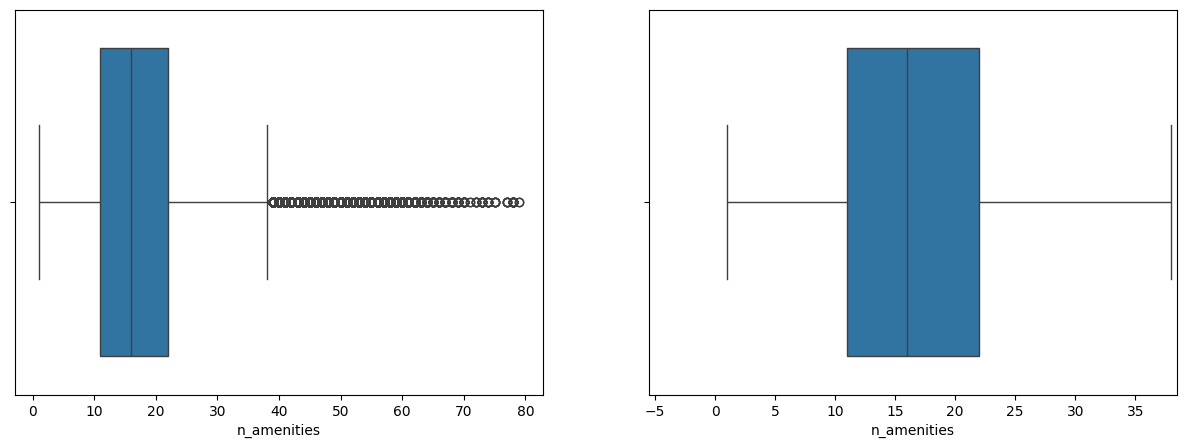

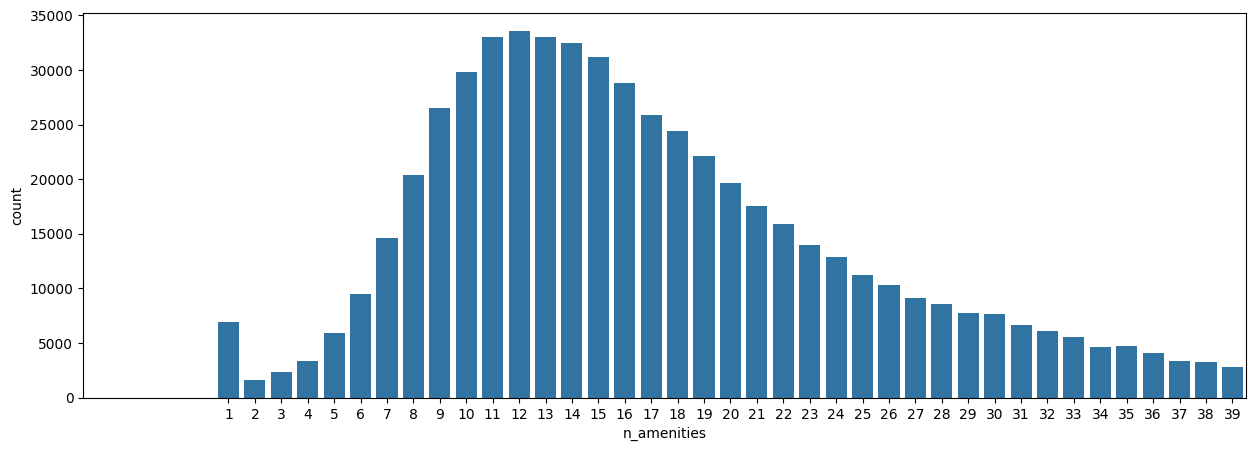

In [30]:
diagrama_caixa(base_airbnb["n_amenities"])
grafico_barra(base_airbnb["n_amenities"])


base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "n_amenities")

print("{} linhas removidas".format(linhas_removidas))

---

## Visualização de Mapa das Propriedades

In [31]:
amostra = base_airbnb.sample(n=50000)
centro_mapa = {"lat": amostra.latitude.mean(), "lon": amostra.longitude.mean()}
mapa = px.density_map(amostra, lat="latitude", lon="longitude", z="price", radius=2.5,
                         center= centro_mapa, zoom=10,
                         map_style="open-street-map")

mapa.show()


---

## Encoding

In [32]:
# Aqui neste bloco que tranformei os valores boolean em 1 e 0

colunas_tf = ['host_is_superhost', 'instant_bookable', 'is_business_travel_ready', 'is_location_exact']
base_airbnb_cod = base_airbnb.copy()

for coluna in colunas_tf:
    base_airbnb_cod[coluna] = base_airbnb_cod[coluna].map({"t": 1, "f": 0})
    


In [33]:
colunas_categoria = ["property_type", "room_type", "bed_type", "cancellation_policy", "is_location_exact"]
base_airbnb_cod = pd.get_dummies(data= base_airbnb_cod, columns= colunas_categoria)
colunas_bool = base_airbnb_cod.select_dtypes(include="bool").columns

base_airbnb_cod[colunas_bool] = base_airbnb_cod[colunas_bool].astype(int)
display(base_airbnb_cod.head())

,host_is_superhost,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,extra_people,...,room_type_Private room,room_type_Shared room,bed_type_Outros,bed_type_Real Bed,cancellation_policy_flexible,cancellation_policy_moderate,cancellation_policy_strict,cancellation_policy_strict_14_with_grace_period,is_location_exact_0,is_location_exact_1
0,0,2.0,-22.96592,-43.17896,5,1.0,2.0,2.0,302.0,57.0,...,0,0,0,1,0,0,0,1,0,1
1,1,3.0,-22.97712,-43.19045,3,1.0,1.0,2.0,161.0,45.0,...,0,0,0,1,0,0,0,1,0,1
2,1,1.0,-22.98302,-43.21427,3,1.0,1.0,2.0,249.0,38.0,...,0,0,0,1,0,0,0,1,0,1
4,1,1.0,-22.98816,-43.19359,3,1.5,1.0,2.0,344.0,57.0,...,0,0,0,1,0,0,0,1,0,1
5,1,1.0,-22.98127,-43.19046,2,1.0,1.0,2.0,222.0,80.0,...,0,0,0,1,0,0,0,1,0,1


In [34]:
plt.close("all")

---

## Definição de Métricas para Avaliação e Comparação dos Modelos

In [35]:
def avaliar_modelo(nome_modelo, y_teste, previsao):
    r2 = r2_score(y_teste, previsao)
    RSME = np.sqrt(mean_squared_error(y_teste, previsao))
    return f"Modelo {nome_modelo}:\nR²:{r2}\nRSME:{RSME}"

### Importando os Modelos de Previsão e Machine Learning

- Obs -> tive que colocar limitações nos em dois modelos pois estavam consumindo muita memória ram, e estava e crashando

In [ ]:
# Criando os modelos

modelo_rf = RandomForestRegressor(n_estimators=50, max_depth=20, random_state=10, n_jobs=1)
modelo_lr = LinearRegression()
modelo_et = ExtraTreesRegressor(n_estimators=50, max_depth=20, random_state=10, n_jobs=1)


modelos = {"RandomForest": modelo_rf,
            "LinearRegression": modelo_lr,
            "ExtraTrees": modelo_et,
           }

y = base_airbnb_cod["price"]
X = base_airbnb_cod.drop("price", axis = 1)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10)

for nome_modelo, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    previsao = modelo.predict(X_test)
    print(avaliar_modelo(nome_modelo, y_test, previsao))

Modelo RandomForest:
R²:0.91875044599753
RSME:75.33186584602383
Modelo LinearRegression:
R²:0.3283798814577671
RSME:216.5858500657869
Modelo ExtraTrees:
R²:0.8544379370014739
RSME:100.8305955877923


,0
bedrooms,0.147592
extra_people,0.107912
bathrooms,0.080546
room_type_Entire home/apt,0.075861
latitude,0.072243
accommodates,0.071786
minimum_nights,0.069243
longitude,0.069045
n_amenities,0.061481
beds,0.043643


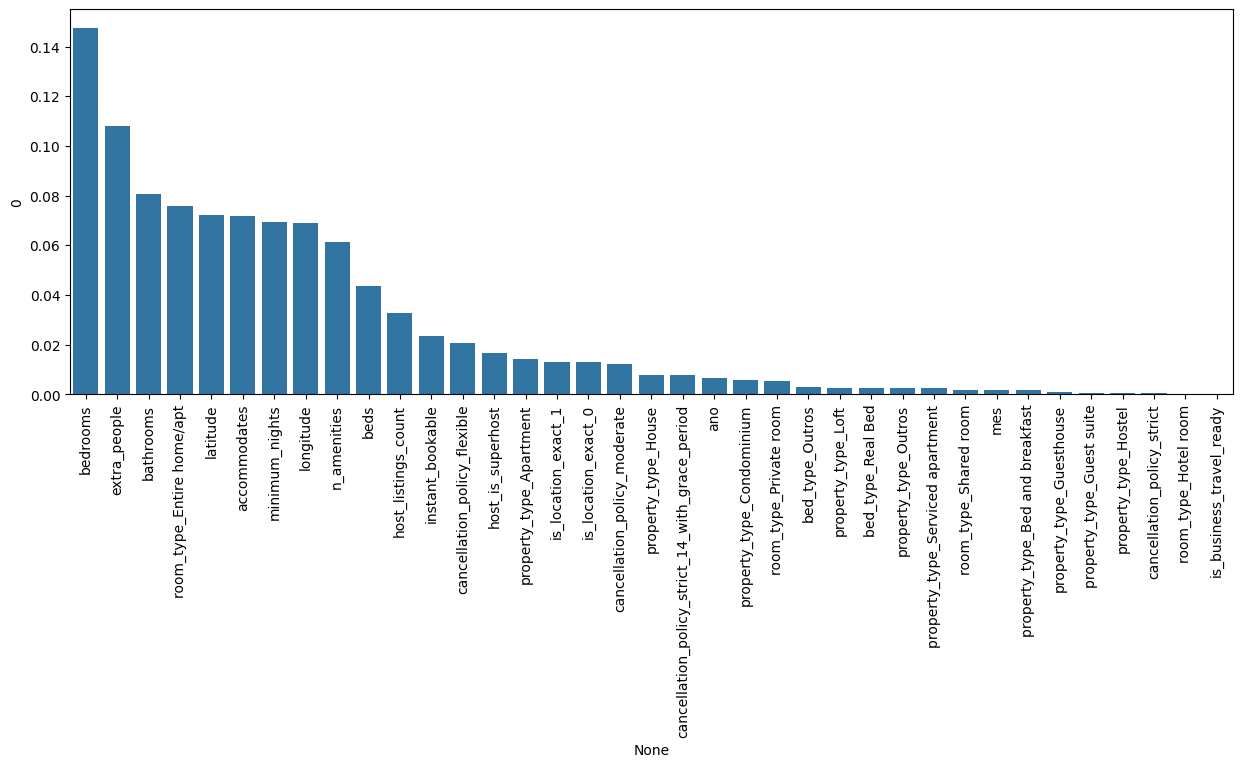

In [38]:
importancia_features = pd.DataFrame(modelo_et.feature_importances_, X_train.columns)
importancia_features = importancia_features.sort_values(by=0, ascending=False)
display(importancia_features)
plt.figure(figsize=(15, 5))
ax = sns.barplot(x = importancia_features.index, y = importancia_features[0])
ax.tick_params(axis="x", rotation=90)

## Criando o arquivo pro streamlit


In [43]:
import joblib

joblib.dump(modelo_rf, "modelo.joblib")


joblib.dump(X.columns.tolist(), "colunas.joblib")


print("Modelo salvo com sucesso!")
print("Colunas slavas com sucesso!")

Modelo salvo com sucesso!
Colunas slavas com sucesso!
